# Problem 01

In [1]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Housing.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/housing-prices-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_1369/2964430592.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'housing-prices-dataset' dataset.
First 5 records:       price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [2]:
df.head(4)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished


In [3]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Select Feature and Target & Convert to NumPy Arrays
# ============================================================

X = df['area'].to_numpy(dtype=float)
y = df['price'].to_numpy(dtype=float)


# ============================================================
# 2. Feature Scaling (Standardization)
# ============================================================

X_mean = np.mean(X)
X_std = np.std(X)

X = (X - X_mean) / X_std

# ============================================================
# 3. Implement MSE Cost Function Manually
# ============================================================

def mse(X, y, w, b):

    cost = 0.0

    m = X.shape[0]

    for i in range(m):

        prediction = w * X[i] + b

        error = prediction - y[i]

        cost += error ** 2


    cost = cost / (2 * m)

    return cost


In [4]:
# ============================================================
# 4. Initial Random Values of Slope and Intercept
# ============================================================

np.random.seed(42)

w_initial = np.random.randn()
b_initial = np.random.randn()


initial_cost = mse(X, y, w_initial, b_initial)


print("Initial slope (w):", w_initial)

print("Initial intercept (b):", b_initial)

print("Initial Cost:", initial_cost)


Initial slope (w): 0.4967141530112327
Initial intercept (b): -0.13826430117118466
Initial Cost: 13106916526203.861


In [5]:
# ============================================================
# 5. Calculate Gradients Manually
# ============================================================

def calculate_gradient(X,y,w,b):
  m = X.shape[0]
  dj_dw = 0.0
  dj_db = 0.0

  for i in range(m):
    pred = w * X[i] + b
    error = (pred - y[i])**2
    dj_dw += error*X[i]
    dj_db += error

  dj_dw = dj_dw/m
  dj_db = dj_db/m
  return dj_dw, dj_db





In [6]:
# 6. Gradient Descent From Scratch

def gradient_descent(X,y,w_input, b_input, iter=100, alpha=0.01):
  w = w_input
  b = b_input
  cost_memory = []
  iter_memory = []
  for i in range(iter):
    dj_dw, dj_db = calculate_gradient(X,y,w,b)

    w = w - alpha*dj_dw
    b = b - alpha*dj_db
    cost = mse(X,y,w,b)

    cost_memory.append(cost)
    iter_memory.append(i)

    if i%100==0:
      print(f"Iteration:{i}, cost:{cost:.4e}, w:{w:.4f}, b:{b:.4f}")
  return w,b,cost_memory, iter_memory

In [7]:
# 7. Train Model for 1000 Iterations
w,b,cost_memory, iter_memory = gradient_descent(X,y,w_input=w_initial,b_input=b_initial, iter=1000)


Iteration:0, cost:4.0629e+22, w:-111973932759.8001, b:-262138330524.2155
Iteration:100, cost:nan, w:nan, b:nan
Iteration:200, cost:nan, w:nan, b:nan


/tmp/ipykernel_1369/2872661683.py:38: RuntimeWarning: overflow encountered in scalar power
  cost += error ** 2
/tmp/ipykernel_1369/3943865776.py:12: RuntimeWarning: overflow encountered in scalar power
  error = (pred - y[i])**2
/tmp/ipykernel_1369/3943865776.py:13: RuntimeWarning: invalid value encountered in scalar add
  dj_dw += error*X[i]


Iteration:300, cost:nan, w:nan, b:nan
Iteration:400, cost:nan, w:nan, b:nan
Iteration:500, cost:nan, w:nan, b:nan
Iteration:600, cost:nan, w:nan, b:nan
Iteration:700, cost:nan, w:nan, b:nan
Iteration:800, cost:nan, w:nan, b:nan
Iteration:900, cost:nan, w:nan, b:nan


# Problem 2: Student Performance Prediction

In [8]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "StudentsPerformance.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "spscientist/students-performance-in-exams",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df.head()

/tmp/ipykernel_1369/3083814728.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'students-performance-in-exams' dataset.


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


```python
Predict math score using reading score. convert them to numpy array from the dataframe
Implement the MSE Cost Function manually.
Compute the gradient formulas manually.
Perform Gradient Descent for 500 iterations.
Print the cost after every 50 iterations.
Plot Cost vs Iteration.


In [9]:
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [10]:
X = df['reading score'].to_numpy(dtype=float)
y = df['math score'].to_numpy(dtype=float)

X_mean = np.mean(X)
X_std = np.std(X)
X = (X-X_mean)/X_std

# mse cost function
def mse(X,y,w,b):
  m = X.shape[0]
  cost = 0.0
  for i in range(m):
    pred = w*X[i] + b
    error = pred - y[i]
    cost += error**2
  cost = cost/(2*m)
  return cost



In [11]:
# gradient descent

def calculate_gradient(X,y,w,b):
  m = X.shape[0]
  dj_dw = 0.0
  dj_db = 0.0
  for i in range(m):
    pred = w * X[i] + b
    error = pred - y[i]
    dj_dw += error * X[i]
    dj_db += error
  dj_dw /= m
  dj_db /= m

  return dj_dw, dj_db

In [12]:
def gradient_descent(X,y, w, b, iter, alpha):
  cost_memory = []
  iter_memory = []
  for i in range(iter):
    dj_dw, dj_db = calculate_gradient(X,y, w,b)
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    cost = mse(X,y,w,b)
    cost_memory.append(cost)
    iter_memory.append(i)

    if(i%50==0):
      print(f"Iteration: {i}, cost: {cost:.4f}")
  return w, b, cost_memory, iter_memory

In [13]:
w_initial = 0.9

b_initial = 67
initial_cost = mse(
    X,
    y,
    w_initial,
    b_initial
)


print("Initial Cost:", initial_cost)

Initial Cost: 104.51275672441439


In [14]:
w_final, b_final, cost_memory, iter_memory = gradient_descent(X,y,w_initial,b_initial, iter=500, alpha=0.01)

Iteration: 0, cost: 103.1907
Iteration: 50, cost: 61.9115
Iteration: 100, cost: 46.8020
Iteration: 150, cost: 41.2714
Iteration: 200, cost: 39.2471
Iteration: 250, cost: 38.5061
Iteration: 300, cost: 38.2349
Iteration: 350, cost: 38.1356
Iteration: 400, cost: 38.0992
Iteration: 450, cost: 38.0859


In [15]:

print("\nFinal Learned Parameters")

print("Final slope (w):", w_final)

print("Final intercept (b):", b_final)

print("Final Cost:", cost_memory[-1])


Final Learned Parameters
Final slope (w): 12.315325585293674
Final intercept (b): 66.09498571005167
Final Cost: 38.081124791984266


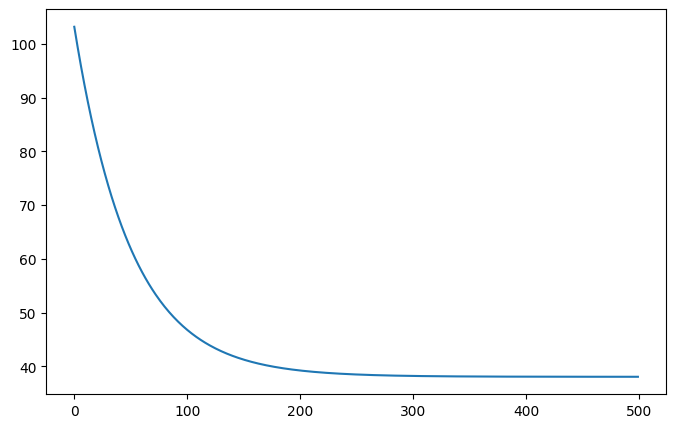

In [16]:
plt.figure(figsize=(8,5))
plt.plot(iter_memory, cost_memory)


In [17]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Salary_Data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "karthickveerakumar/salary-data-simple-linear-regression",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_1369/2496928142.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 454/454 [00:00<00:00, 762kB/s]

First 5 records:    YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0


In [18]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [19]:
X = df['YearsExperience'].to_numpy(dtype=float)
y = df['Salary'].to_numpy(dtype=float)

In [20]:
# feature scaling
X_mean = np.mean(X)
X_std = np.std(X)
X = (X - X_mean)/X_std

np.random.seed(42)
w = np.random.randn()
b = np.random.randn()

print("Initial w:", w)
print("Initial b:", b)

# calculate MSE cost function
def mse(X,y,w,b):
  m = X.shape[0]
  cost = 0.0
  for i in range(m):
    pred = w * X[i] +b
    error = pred - y[i]
    cost += error**2
  total_cost = cost/(2*m)
  return total_cost


Initial w: 0.4967141530112327
Initial b: -0.13826430117118466


In [21]:
initial_cost = mse(X,y,w,b)
print(initial_cost)

3251475047.048575


In [22]:
# calculate gradient
def calculate_gradient(X,y,w,b):
  m =  X.shape[0]
  dj_dw = 0.0
  dj_db = 0.0
  for i in range(m):
    pred = w*X[i] + b
    error = pred - y[i]
    dj_dw += error * X[i]
    dj_db += error

  dj_dw = dj_dw/m
  dj_db = dj_db/m
  return dj_dw, dj_db

# Gradient Descent
def gradient_descent(X,y,w,b,learning_rate, iter):
  cost_memory = []


  for i in range(iter):
    dj_dw, dj_db = calculate_gradient(X,y,w,b)
    w = w - learning_rate*dj_dw
    b = b - learning_rate*dj_db

    cost = mse(X,y,w,b)
    cost_memory.append(cost)
    if i%100==0:
      print(f"at iteration i={i}, cost={cost:.4f}, w={w:.4f}, b={b:.4f}")
  return w,b,cost_memory

In [23]:
learning_rate = 0.01
iterations = 1000

w_final, b_final, cost_history = gradient_descent(X,y,w,b,learning_rate, iterations)

at iteration i=0, cost=3187081839.5819, w=264.1636, b=759.8931
at iteration i=100, cost=440544828.5019, w=16812.6333, b=48461.5894
at iteration i=200, cost=72564692.7721, w=22869.9085, b=65921.9530
at iteration i=300, cost=23262833.8328, w=25087.0671, b=72313.0108
at iteration i=400, cost=16657386.8022, w=25898.6188, b=74652.3446
at iteration i=500, cost=15772391.1568, w=26195.6730, b=75508.6164
at iteration i=600, cost=15653819.7279, w=26304.4044, b=75822.0396
at iteration i=700, cost=15637933.5664, w=26344.2037, b=75936.7627
at iteration i=800, cost=15635805.1437, w=26358.7715, b=75978.7550
at iteration i=900, cost=15635519.9783, w=26364.1038, b=75994.1255


In [24]:
final_cost = mse(X, y, w_final, b_final)


print("\nTraining Completed")

print("Final w:", w_final)

print("Final b:", b_final)

print("Final Cost:", final_cost)


Training Completed
Final w: 26366.04416082941
Final b: 75999.71884971406
Final Cost: 15635481.891957846


In [25]:
y_pred = w_final * X + b_final

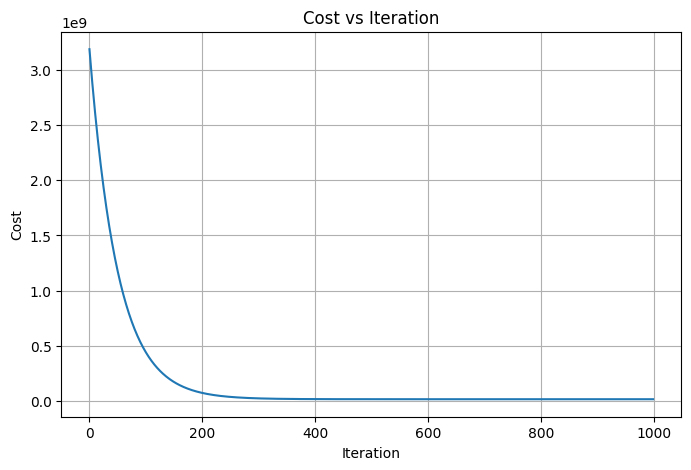

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(range(iterations), cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs Iteration")
plt.grid()
plt.show()

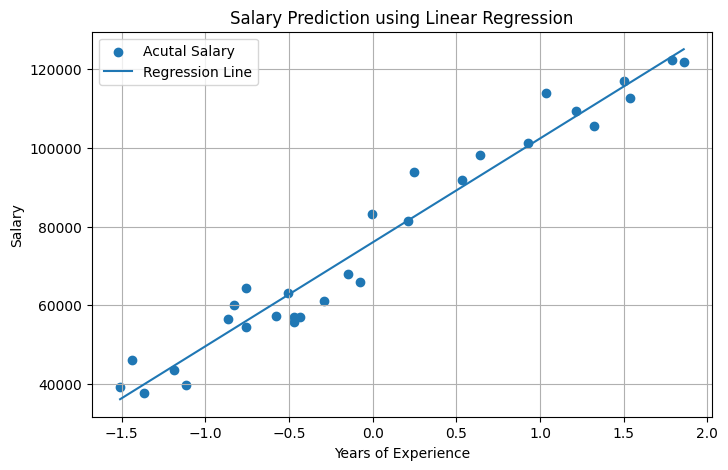

In [27]:
# ploting regression line

plt.figure(figsize=(8,5))
plt.scatter(X,y,label="Acutal Salary")
sorted_index = np.argsort(X) # sorting X for smooth regression line
X_sorted = X[sorted_index]
y_pred_sorted = y_pred[sorted_index]

plt.plot(
    X_sorted,
    y_pred_sorted,
    label="Regression Line"
)
plt.xlabel("Years of Experience")

plt.ylabel("Salary")

plt.title("Salary Prediction using Linear Regression")

plt.legend()

plt.grid()

plt.show()